In [1]:
import numpy as np
import os, sys 
import re
import ROOT
ROOT.gStyle.SetOptStat(0)
import array
from cats.cdataframe import CDataFrame
from CDMSDataCatalog import CDMSDataCatalog
import glob
import pandas as pd

import matplotlib.pyplot as plt
from linearization import linearization
import read_relcal
%matplotlib inline

CDMS = os.environ["CDMS"] # set in .bash_profile

sys.path.append(os.path.join(os.path.join(CDMS,"scripts")))
from ROOplot import ROOplot

Welcome to JupyROOT 6.28/10


In [2]:
## R37 Z1 low bg 50V
series_list=['23240109_075338', '23240109_021236', '23240108_203134', '23231221_101235', '23231221_015705', '23231220_190923', '23231220_122140', '23231220_053358', '23231220_012745', '23231219_184002', 
             '23231219_110331', '23231219_034952', '23231218_223530', '23231218_190035', '23231218_152721', '23231218_093255', '23231218_024511', '23231217_212512', '23231217_171613', '23231217_135018', 
             '23231216_233807', '23231216_211119', '23231216_194929', '23231216_182937', '23231216_173436', '23231216_145300', '23231216_100125', '23231216_043946', '23231216_013604']
ProdTag = 'CUTE_T3GeCalib_NxM_P4.0.0_V05-06_C0.3.6'

In [3]:
## Use DataCat to pull the series
dc = CDMSDataCatalog().findData(
    Facility    = "CUTE",
    nFridgeRun  = 37,
    Series      = series_list,
    ProdTag     = ProdTag,
    nMergeLevel = 1,
    dofetch     = True
)
RQfiles_data = [x.filePath for x in dc]

In [4]:
fp = "/sdf/data/supercdms/workarea/simulations/wperry/" ## this is the global file path the DMC data is saved in on compute canada

## Define the filepaths used
samples = {"L": "Ge71_Lshell_pos50V_V05-09",
           "K": "Ge71_Kshell_pos50V_100kEvents_V05-09",
           "Pb": "HV100mm_Pb210_50V"}
truth =   {"L": "/DMCOutput/*.root",
           "K": "/DMCOutput/R*/*.root",
           "Pb": "/DMCOutput/*.root"}
proc =    {"L": "/Processed/Unmerged/*/*.root",
           "K": "/Processed_fixedTemplates/R*/Unmerged/*/*.root",
           "Pb": "/Processed/Unmerged/*/*.root"}

In [5]:
## Get the file names in these folders
RQfiles_K, RQfiles_L, RQfiles_Pb = np.sort(glob.glob(fp+samples["K"]+proc["K"])), np.sort(glob.glob(fp+samples["L"]+proc["L"])), np.sort(glob.glob(fp+samples["Pb"]+proc["Pb"]))
truthfiles_K, truthfiles_L, truthfiles_Pb = np.sort(glob.glob(fp+samples["K"]+truth["K"])), np.sort(glob.glob(fp+samples["L"]+truth["L"])), np.sort(glob.glob(fp+samples["Pb"]+truth["Pb"]))

 ## simulation truth
DMChit_K = CDataFrame("G4SimDir/g4dmcHits", truthfiles_K)
#DMCzip_K = CDataFrame("G4SimDir/mczip0", truthfiles_K)
DMChit_Pb = CDataFrame("G4SimDir/g4dmcHits", truthfiles_Pb)
#DMCzip_Pb = CDataFrame("G4SimDir/mczip0", truthfiles_Pb)

In [6]:
config_path = "/sdf/home/p/perrywar/cdmsbats_config/UserSettings/BatRootSettings/analysis/"
config_sim = "DMCData.HV100mm_uni_triangle"
config_data = "configCUTEData.NxM.50VZ1Z30VZ6.V4.0.0"
relcal_path = {'K':  config_path+config_sim,
               'Pb':  config_path+config_sim,
               'sim':  config_path+config_sim,
               'data': config_path+config_data}

det     = {'sim': 1, 'K': 1, 'Pb': 1, 'data': 1}
trigdet = {'sim': 0, 'K': 1, 'Pb': 0, 'data': 1}

In [10]:
channels = [f"P{letter}S{side}" for side in [1, 2] for letter in ["A", "B", "C", "D", "E", "F"]]
RQ_branches = ["PTOFamps", "PTOFchisqLF", "PTOFdelay", "EventTriggerID"] + [chan + "OFamps" for chan in channels] + [chan + "OFchisqLF" for chan in channels] + [chan + "OFdelay" for chan in channels]
DMC_branches = ["EventNum", "X", "Y", "Z", "trueEnergy"]
keVt2keVee = 1/(1 + 50/3) # inverse of Luke gain factor
lin2keVee = {'sim': 210e2 * keVt2keVee, 'data': 210e2 * keVt2keVee} # (keVt/linAmp) * (keVee / keVt)
RQs = {}

In [11]:
## load relevant RQs for data
df = CDataFrame("rqDir/zip"+str(det["data"]), RQfiles_data, friends = [[x+":rqDir/eventTree" for x in RQfiles_data]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_filtered = df.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["data"]), "PTOFamps>0"])
RQs["data"] = df_filtered.AsNumpy(RQ_branches)

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["data"], 'PTOFamps', 'unbinned')
RQs["data"]['lin_PTOFamps'] = lin_class.linearize(RQs["data"]['PTOFamps'])
RQs["data"]['calib_PTOFamps'] = RQs["data"]['lin_PTOFamps'] * lin2keVee["data"]

In [12]:
## load relevant RQs for simulation
df_K = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_K, friends = [[x+":rqDir/eventTree" for x in RQfiles_K]])
df_Pb = CDataFrame("rqDir/zip"+str(det["sim"]), RQfiles_Pb, friends = [[x+":rqDir/eventTree" for x in RQfiles_Pb]])
    
## Apply some basic data quality filters and get the RQs you're interested in
df_K_filtered = df_K.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>0"])
df_Pb_filtered = df_Pb.Filters(["TriggerType == 1", "TriggerDetectorNum=="+str(trigdet["sim"]), "PTOFamps>0"])
RQs_K = df_K_filtered.AsNumpy(RQ_branches)
RQs_Pb = df_Pb_filtered.AsNumpy(RQ_branches)

# deal with CDMSSIM-451
for branch in channels + ['PT']:
    RQs_K[branch + 'OFamps'] *= 10/4
    RQs_Pb[branch + 'OFamps'] *= 10/4

# combine truth data with RQs
hits_K = pd.DataFrame(DMChit_K.AsNumpy(DMC_branches))
hits_Pb = pd.DataFrame(DMChit_Pb.AsNumpy(DMC_branches))

#hits_Pb_mean = (
#    hits_Pb
#    .groupby('EventNum', as_index=False)
#    .mean(numeric_only=True)
#)

hits_Pb_mean = (
    hits_Pb
    .groupby("EventNum", as_index=False)
    .agg(
        X=("X", "mean"),
        Y=("Y", "mean"),
        Z=("Z", "mean"),
        trueEnergy=("trueEnergy", "sum"),
    )
)

hits_K = hits_K.rename(columns={'EventNum': 'EventTriggerID'})
hits_Pb_mean = hits_Pb_mean.rename(columns={'EventNum': 'EventTriggerID'})

# Construct and return the single dataframe with the info we care about
merged_K = pd.merge(pd.DataFrame(RQs_K), hits_K, on='EventTriggerID', how='inner')
merged_Pb = pd.merge(pd.DataFrame(RQs_Pb), hits_Pb_mean, on='EventTriggerID', how='inner')

RQs['K'] = merged_K
RQs['Pb'] = merged_Pb
RQs['K']['R'] = np.sqrt(RQs['K']['X']**2 + RQs['K']['Y']**2)
RQs['Pb']['R'] = np.sqrt(RQs['Pb']['X']**2 + RQs['Pb']['Y']**2)

## linearize and calibrate PTOFamps to keVee
lin_class = linearization(det["sim"], 'PTOFamps', 'unbinned')
RQs["K"]['lin_PTOFamps'] = lin_class.linearize(RQs["K"]['PTOFamps'])
RQs["Pb"]['lin_PTOFamps'] = lin_class.linearize(RQs["Pb"]['PTOFamps'])
RQs["K"]['calib_PTOFamps'] = RQs["K"]['lin_PTOFamps'] * lin2keVee["sim"]
RQs["Pb"]['calib_PTOFamps'] = RQs["Pb"]['lin_PTOFamps'] * lin2keVee["sim"]

In [13]:
def apply_relative_cal(datatype):
    rel_calibs = read_relcal.get_rel_calib(relcal_path[datatype])
    for chan in channels:
        RQs[datatype][chan+'OFamps'] *= rel_calibs[det[datatype]][chan]

In [14]:
## Calculate radial parameter from channel amplitudes
for datatype in ['data', 'K', 'Pb']:
    apply_relative_cal(datatype)
    Fsum = RQs[datatype]['PFS1OFamps'] + RQs[datatype]['PFS2OFamps']
    Asum = RQs[datatype]['PAS1OFamps'] + RQs[datatype]['PAS2OFamps']
    RQs[datatype]['RadialPar'] = (Fsum - Asum) / RQs[datatype]['PTOFamps']
    RQs[datatype]['RadialPar1'] = (RQs[datatype]['PFS1OFamps'] - RQs[datatype]['PAS1OFamps']) / RQs[datatype]['PTOFamps'] * 2
    RQs[datatype]['RadialPar2'] = (RQs[datatype]['PFS2OFamps'] - RQs[datatype]['PAS2OFamps']) / RQs[datatype]['PTOFamps'] * 2

In [15]:
## Calculate common quantities  for plotting
for datatype in ['data', 'K', 'Pb']:
    RQs[datatype]['A'] = RQs[datatype]['PAS1OFamps'] + RQs[datatype]['PAS2OFamps']
    RQs[datatype]['B'] = RQs[datatype]['PBS1OFamps'] + RQs[datatype]['PBS2OFamps']
    RQs[datatype]['CDE'] = (RQs[datatype]['PCS1OFamps'] + RQs[datatype]['PCS2OFamps'] + 
                            RQs[datatype]['PDS1OFamps'] + RQs[datatype]['PDS2OFamps'] + 
                            RQs[datatype]['PES1OFamps'] + RQs[datatype]['PES2OFamps'])
    RQs[datatype]['F'] = RQs[datatype]['PFS1OFamps'] + RQs[datatype]['PFS2OFamps']

In [16]:
RQs['K'] = RQs['K'].to_dict(orient='list')
RQs['Pb'] = RQs['Pb'].to_dict(orient='list')
for key in list(RQs['K'].keys()):
    RQs['K'][key] = np.array(RQs['K'][key])
    RQs['Pb'][key] = np.array(RQs['Pb'][key])

In [17]:
## Set of cuts for selecting events in different regions of the Ge-71 spectrum. Bounds often set by the +/-3 sigma edges of the peaks. Fit results taken from here:
# https://confluence.slac.stanford.edu/spaces/CDMS/pages/601696559/Comparing+Ge+activation+rates+in+data+and+simulation
bounds = {'sim': {'K': {'lower': 9.9632 - 3*0.1209,
                        'upper': 9.9632 + 3*0.1209},
                  'L': {'lower': 1.2512 - 3*0.0240,
                        'upper': 1.2512 + 3*0.0240}},
          'data':{'K': {'lower': 10.08 - 3*0.23,
                        'upper': 10.63 + 3*0.2},
                  'L': {'lower': 1.280 - 3*0.063,
                        'upper': 1.280 + 3*0.063}}}

RQs['K']['Kshell_cut']  = (RQs['K']['calib_PTOFamps'] < bounds['sim']['K']['upper']) & (RQs['K']['calib_PTOFamps'] > bounds['sim']['L']['upper'])
RQs['Pb']['Kshell_cut']  = (RQs['Pb']['calib_PTOFamps'] < bounds['sim']['K']['upper']) & (RQs['Pb']['calib_PTOFamps'] > bounds['sim']['L']['upper'])
RQs['data']['Kshell_cut'] = (RQs['data']['calib_PTOFamps'] < bounds['data']['K']['upper']) & (RQs['data']['calib_PTOFamps'] > bounds['data']['L']['upper'])

In [21]:
max(RQs['Pb']['trueEnergy'][RQs['Pb']['Kshell_cut']]*1e-3)

60.11015832603797

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


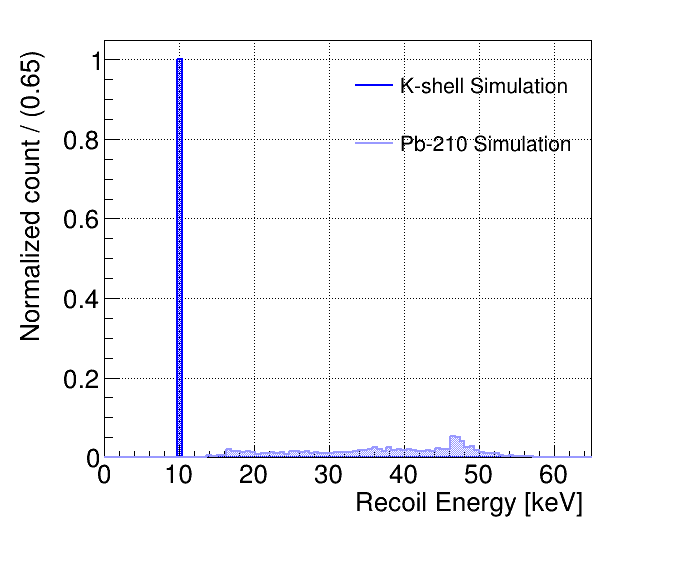

In [25]:
bins_start, bins_end, nbins = 0, 65, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Recoil Energy [keV]", _ylabel="Normalized count / (" + str(binwidth) + ")")

plt.createHist(RQs['K']['trueEnergy'][RQs['K']['Kshell_cut']]*1e-3, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue, fillstyle=3001, scale=sum(RQs['K']['Kshell_cut']), label="K-shell Simulation")
plt.createHist(RQs['Pb']['trueEnergy'][RQs['Pb']['Kshell_cut']]*1e-3, bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue-9, fillstyle=3001, scale=sum(RQs['Pb']['Kshell_cut']), label="Pb-210 Simulation")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.5, 0.7, 0.8, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


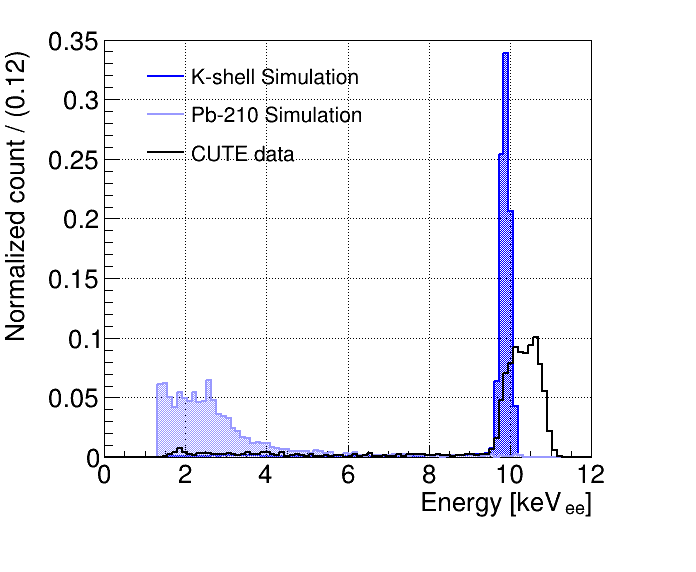

In [20]:
bins_start, bins_end, nbins = 0, 12, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.35)

plt.createHist(RQs['K']['calib_PTOFamps'][RQs['K']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue, fillstyle=3001, scale=sum(RQs['K']['Kshell_cut']), label="K-shell Simulation")
plt.createHist(RQs['Pb']['calib_PTOFamps'][RQs['Pb']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue-9, fillstyle=3001, scale=sum(RQs['Pb']['Kshell_cut']), label="Pb-210 Simulation")
plt.createHist(RQs['data']['calib_PTOFamps'][RQs['data']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, scale=sum(RQs['data']['Kshell_cut']), label="CUTE data")

graphs = plt.getGraphs()
plt.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.2, 0.7, 0.5, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


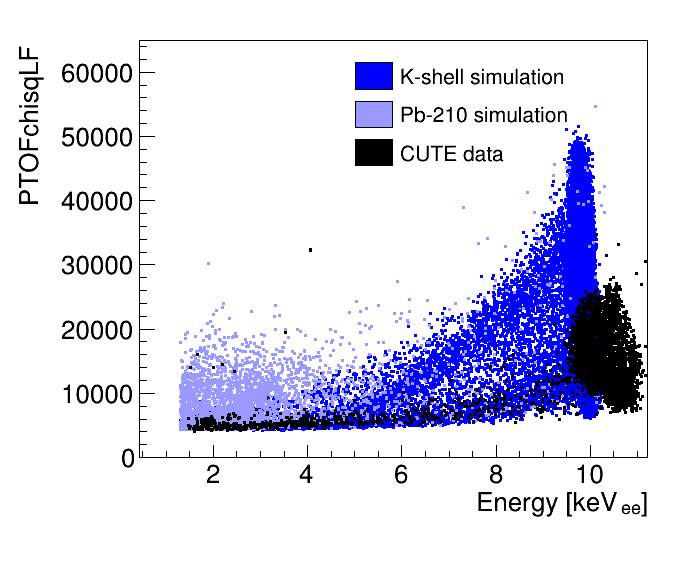

In [21]:
plt = ROOplot(_xlabel="Energy [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="PTOFchisqLF", _leftMargin=0.2, _rightMargin=0.07, _ylim=True, _ylow=0, _yhigh=65000)
plt.createScatter(RQs['K']['calib_PTOFamps'][RQs['K']['Kshell_cut']], RQs['K']['PTOFchisqLF'][RQs['K']['Kshell_cut']], color = ROOT.kBlue, size = 0.4, label = 'K-shell simulation')
plt.createScatter(RQs['Pb']['calib_PTOFamps'][RQs['Pb']['Kshell_cut']], RQs['Pb']['PTOFchisqLF'][RQs['Pb']['Kshell_cut']], color = ROOT.kBlue-9, size = 0.4, label = 'Pb-210 simulation')
plt.createScatter(RQs['data']['calib_PTOFamps'][RQs['data']['Kshell_cut']], RQs['data']['PTOFchisqLF'][RQs['data']['Kshell_cut']], color=ROOT.kBlack, size = 0.4, label = 'CUTE data')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.5, 0.7, 0.8, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


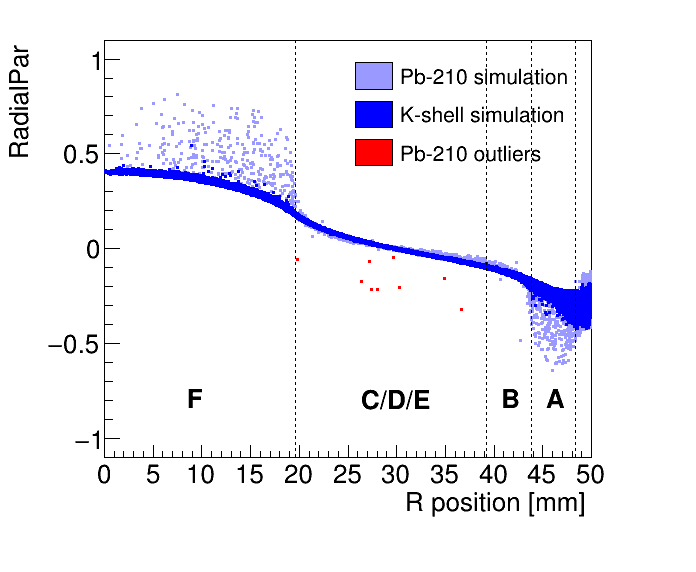

In [53]:
plt = ROOplot(_xlabel="R position [mm]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-1.1, _yhigh=1.1)
plt.createScatter(RQs['Pb']['R'][RQs['Pb']['Kshell_cut']]*1e3, RQs['Pb']['RadialPar'][RQs['Pb']['Kshell_cut']], color = ROOT.kBlue-9, size = 0.4, label = 'Pb-210 simulation')
plt.createScatter(RQs['K']['R'][RQs['K']['Kshell_cut']]*1e3, RQs['K']['RadialPar'][RQs['K']['Kshell_cut']], color = ROOT.kBlue, size = 0.4, label = 'K-shell simulation')

cut1 = (RQs['Pb']['R']*1e3 < 31) & (RQs['Pb']['R']*1e3 > 19) & (RQs['Pb']['RadialPar'] < -0.02)
cut2 = (RQs['Pb']['R']*1e3 < 37) & (RQs['Pb']['R']*1e3 > 31) & (RQs['Pb']['RadialPar'] < -0.08)
cut = cut1 | cut2
plt.createScatter(RQs['Pb']['R'][RQs['Pb']['Kshell_cut'] & cut]*1e3, RQs['Pb']['RadialPar'][RQs['Pb']['Kshell_cut'] & cut], color = ROOT.kRed, size = 0.4, label = 'Pb-210 outliers')


graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.5, 0.7, 0.8, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.Draw()

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

latex.DrawLatex(0.27, 0.32, "F")
latex.DrawLatex(0.52, 0.32, "C/D/E")
latex.DrawLatex(0.72, 0.32, "B")
latex.DrawLatex(0.785, 0.32, "A")

lineF = ROOT.TLine(19.592, -1.1, 19.592, 1.1)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -1.1, 39.192, 1.1)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -1.1, 43.818, 1.1)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -1.1, 48.3, 1.1)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


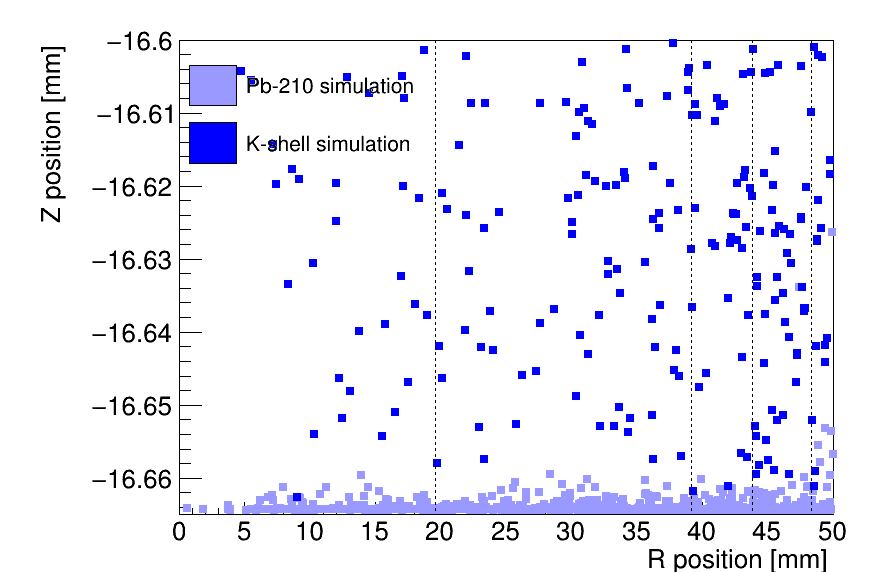

In [25]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=-16.6)

plt.createScatter(RQs['Pb']['R'][RQs['Pb']['Kshell_cut']]*1e3, RQs['Pb']['Z'][RQs['Pb']['Kshell_cut']]*1e3, color = ROOT.kBlue-9, size = 1, label = 'Pb-210 simulation')
plt.createScatter(RQs['K']['R'][RQs['K']['Kshell_cut']]*1e3, RQs['K']['Z'][RQs['K']['Kshell_cut']]*1e3, color = ROOT.kBlue, size = 1, label = 'K-shell simulation')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.2, 0.7, 0.5, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.Draw()

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, -16.6)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, -16.6)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, -16.6)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, -16.6)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


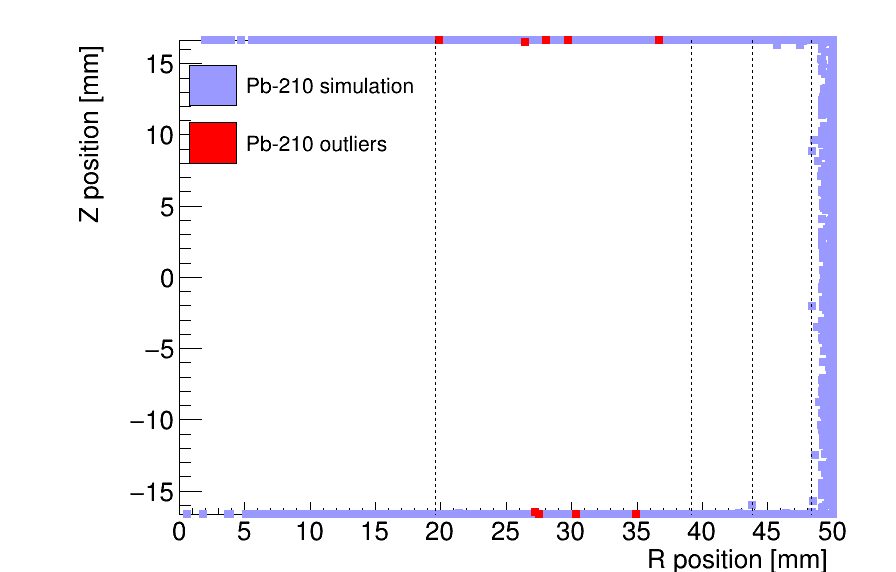

In [54]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

plt.createScatter(RQs['Pb']['R'][RQs['Pb']['Kshell_cut']]*1e3, RQs['Pb']['Z'][RQs['Pb']['Kshell_cut']]*1e3, color = ROOT.kBlue-9, size = 1, label = 'Pb-210 simulation')
#plt.createScatter(RQs['K']['R'][RQs['K']['Kshell_cut']]*1e3, RQs['K']['Z'][RQs['K']['Kshell_cut']]*1e3, color = ROOT.kBlue, size = 1, label = 'K-shell simulation')
plt.createScatter(RQs['Pb']['R'][RQs['Pb']['Kshell_cut'] & cut]*1e3, RQs['Pb']['Z'][RQs['Pb']['Kshell_cut'] & cut]*1e3, color = ROOT.kRed, size = 1, label = 'Pb-210 outliers')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.2, 0.7, 0.5, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.Draw()

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


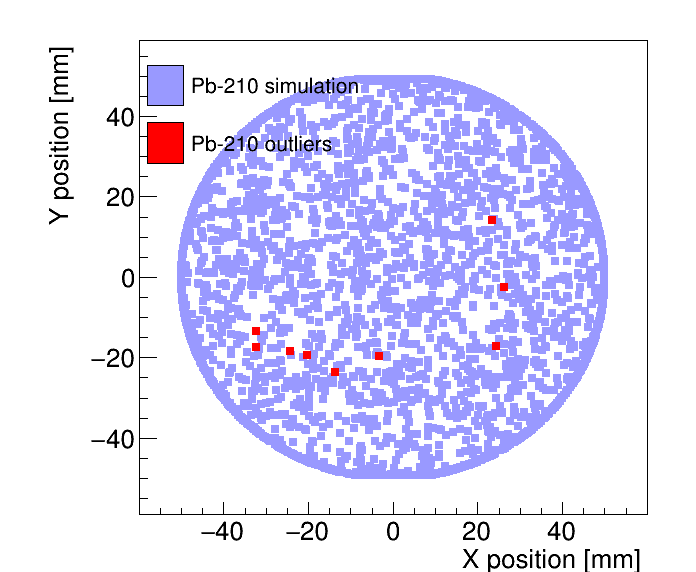

In [55]:
plt = ROOplot(_xlabel="X position [mm]", _ylabel="Y position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1)

plt.createScatter(RQs['Pb']['X'][RQs['Pb']['Kshell_cut']]*1e3, RQs['Pb']['Y'][RQs['Pb']['Kshell_cut']]*1e3, color = ROOT.kBlue-9, size = 1, label = 'Pb-210 simulation')
#plt.createScatter(RQs['K']['R'][RQs['K']['Kshell_cut']]*1e3, RQs['K']['Z'][RQs['K']['Kshell_cut']]*1e3, color = ROOT.kBlue, size = 1, label = 'K-shell simulation')
plt.createScatter(RQs['Pb']['X'][RQs['Pb']['Kshell_cut'] & cut]*1e3, RQs['Pb']['Y'][RQs['Pb']['Kshell_cut'] & cut]*1e3, color = ROOT.kRed, size = 1, label = 'Pb-210 outliers')

graphs = plt.getGraphs()
plt.draw("AP", "P ")

legend = ROOT.TLegend(0.2, 0.7, 0.5, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


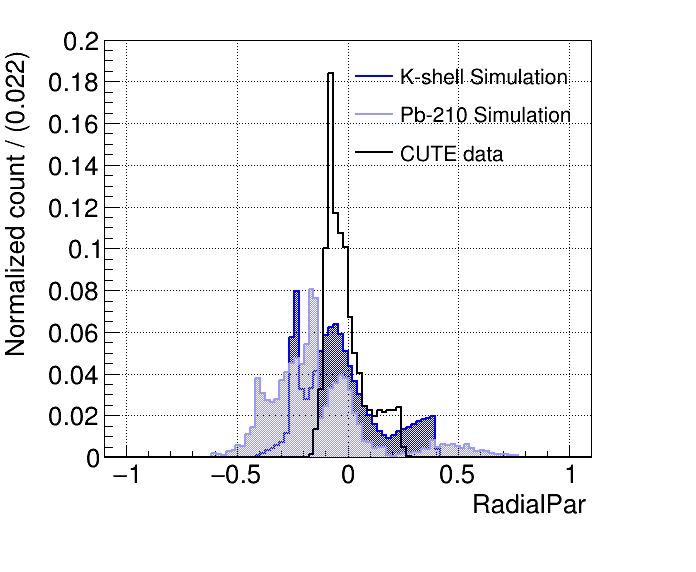

In [26]:
bins_start, bins_end, nbins = -1.1, 1.1, 100
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")", _ylim=True, _ylow=0, _yhigh=0.2)

hist.createHist(RQs['K']['RadialPar'][RQs['K']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue, fillstyle=3001, scale=sum(RQs['K']['Kshell_cut']), label="K-shell Simulation")
hist.createHist(RQs['Pb']['RadialPar'][RQs['Pb']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlue-9, fillstyle=3001, scale=sum(RQs['Pb']['Kshell_cut']), label="Pb-210 Simulation")
hist.createHist(RQs['data']['RadialPar'][RQs['data']['Kshell_cut']], bins_start, bins_end, nbins, width = 2, color=ROOT.kBlack, scale=sum(RQs['data']['Kshell_cut']), label="CUTE data")

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

legend = ROOT.TLegend(0.5, 0.7, 0.8, 0.9)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "l")

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


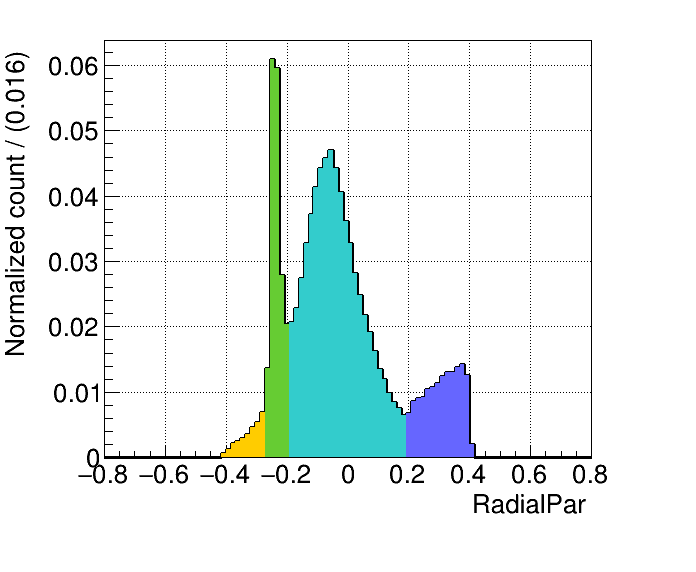

In [23]:
bins_start, bins_end, nbins = -0.8, 0.8, 100
bin_edges = np.linspace(bins_start, bins_end, nbins + 1)
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

hist.createHist(RQs['K']['RadialPar'][RQs['K']['Kshell_cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlack, scale=sum(RQs['K']['Kshell_cut']))

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] < bin_edges[33])
hist.createHist(RQs['K']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kOrange, scale=sum(RQs['K']['Kshell_cut']))

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[33]) & (RQs['K']['RadialPar'] < bin_edges[38])
hist.createHist(RQs['K']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kSpring-5, scale=sum(RQs['K']['Kshell_cut']))

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[38]) & (RQs['K']['RadialPar'] < bin_edges[62])
hist.createHist(RQs['K']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kCyan-3, scale=sum(RQs['K']['Kshell_cut']))

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[62])
hist.createHist(RQs['K']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kBlue-7, scale=sum(RQs['K']['Kshell_cut']))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


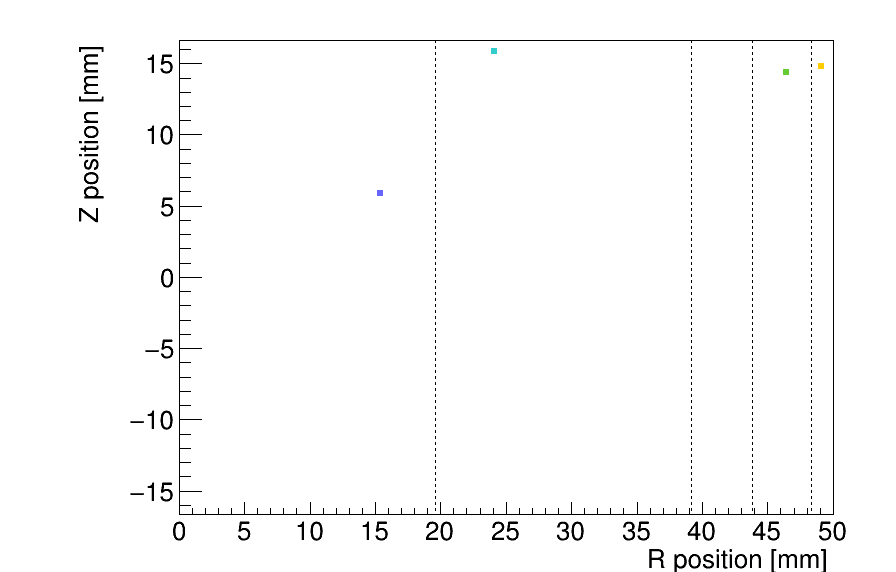

In [24]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] < bin_edges[33])
plt.createScatter(np.array([RQs['K']['R'][cut][0]*1e3]), np.array([RQs['K']['Z'][cut][0]*1e3]), color = ROOT.kOrange, size = 0.8)

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[33]) & (RQs['K']['RadialPar'] < bin_edges[38])
plt.createScatter(np.array([RQs['K']['R'][cut][0]*1e3]), np.array([RQs['K']['Z'][cut][0]*1e3]), color = ROOT.kSpring-5, size = 0.8)

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[38]) & (RQs['K']['RadialPar'] < bin_edges[62])
plt.createScatter(np.array([RQs['K']['R'][cut][0]*1e3]), np.array([RQs['K']['Z'][cut][0]*1e3]), color = ROOT.kCyan-3, size = 0.8)

cut = (RQs['K']['Kshell_cut']) & (RQs['K']['RadialPar'] >= bin_edges[62])
plt.createScatter(np.array([RQs['K']['R'][cut][0]*1e3]), np.array([RQs['K']['Z'][cut][0]*1e3]), color = ROOT.kBlue-7, size = 0.8)
plt.draw("AP", "P ")

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).


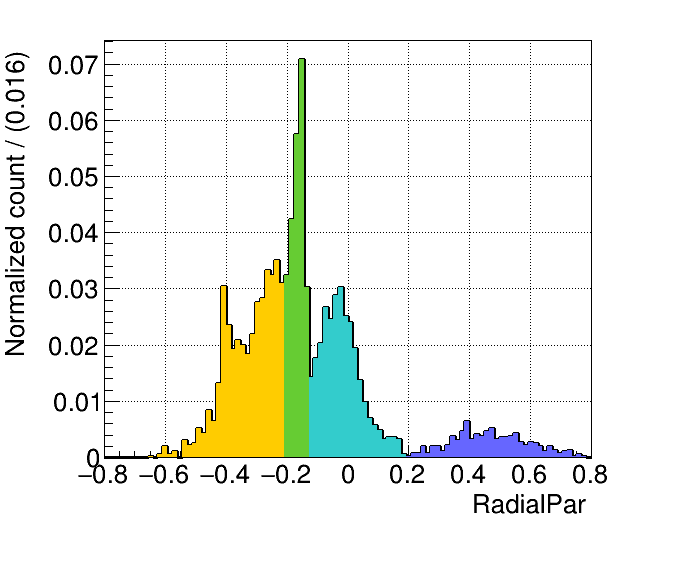

In [33]:
bins_start, bins_end, nbins = -0.8, 0.8, 100
bin_edges = np.linspace(bins_start, bins_end, nbins + 1)
binwidth = np.round((bins_end - bins_start) / nbins, 3)

hist = ROOplot(_xlabel="RadialPar", _ylabel="Normalized count / (" + str(binwidth) + ")")

hist.createHist(RQs['Pb']['RadialPar'][RQs['Pb']['Kshell_cut']], bins_start, bins_end, nbins, width = 3, color=ROOT.kBlack, scale=sum(RQs['Pb']['Kshell_cut']))

cut = (RQs['Pb']['Kshell_cut']) & (RQs['Pb']['RadialPar'] < bin_edges[37])
hist.createHist(RQs['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kOrange, scale=sum(RQs['Pb']['Kshell_cut']))

cut = (RQs['Pb']['Kshell_cut']) & (RQs['Pb']['RadialPar'] >= bin_edges[37]) & (RQs['Pb']['RadialPar'] < bin_edges[42])
hist.createHist(RQs['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kSpring-5, scale=sum(RQs['Pb']['Kshell_cut']))

cut = (RQs['Pb']['Kshell_cut']) & (RQs['Pb']['RadialPar'] >= bin_edges[42]) & (RQs['Pb']['RadialPar'] < bin_edges[62])
hist.createHist(RQs['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kCyan-3, scale=sum(RQs['Pb']['Kshell_cut']))

cut = (RQs['Pb']['Kshell_cut']) & (RQs['Pb']['RadialPar'] >= bin_edges[62])
hist.createHist(RQs['Pb']['RadialPar'][cut], bins_start, bins_end, nbins, width = 0, fillstyle=1001, color=ROOT.kBlue-7, scale=sum(RQs['Pb']['Kshell_cut']))

graphs = hist.getGraphs()
hist.draw("HIST", "HIST ", grid=True)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


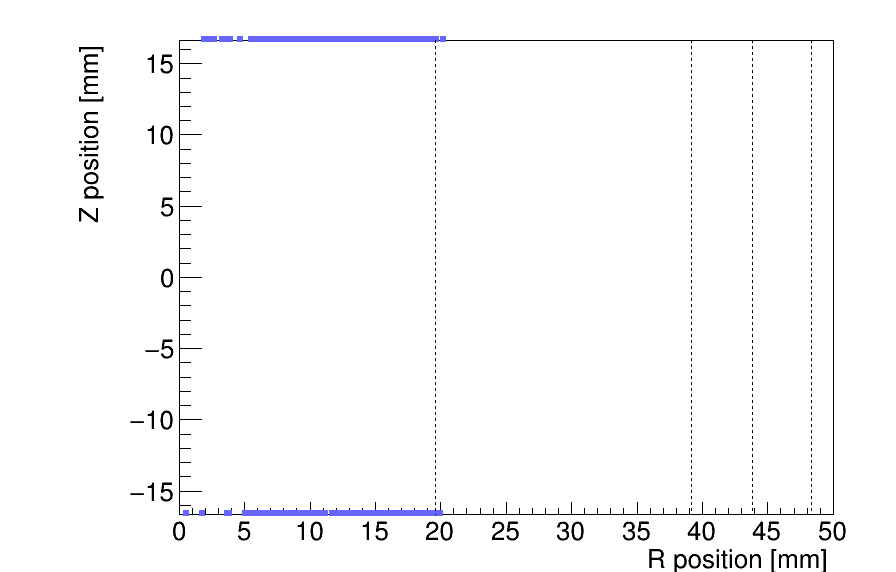

In [35]:
plt = ROOplot(900, 600, _xlabel="R position [mm]", _ylabel="Z position [mm]", _leftMargin=0.2, _rightMargin=0.07, _topMargin=0.07, _bottomMargin=0.1, 
                       _xlim=True, _xlow=0, _xhigh=50, _ylim=True, _ylow=-33.33/2, _yhigh=33.33/2)

#cut = (RQs['Pb']['RadialPar'] < bin_edges[37]) & (RQs['Pb']['Kshell_cut'])
#plt.createScatter(RQs['Pb']['R'][cut]*1e3, RQs['Pb']['Z'][cut]*1e3, color = ROOT.kOrange, size = 0.8)

#cut = (RQs['Pb']['RadialPar'] >= bin_edges[37]) & (RQs['Pb']['RadialPar'] < bin_edges[42]) & (RQs['Pb']['Kshell_cut'])
#plt.createScatter(RQs['Pb']['R'][cut]*1e3, RQs['Pb']['Z'][cut]*1e3, color = ROOT.kSpring-5, size = 0.8)

#cut = (RQs['Pb']['RadialPar'] >= bin_edges[42]) & (RQs['Pb']['RadialPar'] < bin_edges[62]) & (RQs['Pb']['Kshell_cut'])
#plt.createScatter(RQs['Pb']['R'][cut]*1e3, RQs['Pb']['Z'][cut]*1e3, color = ROOT.kCyan-3, size = 0.8)

cut = (RQs['Pb']['RadialPar'] >= bin_edges[62]) & (RQs['Pb']['Kshell_cut'])
plt.createScatter(RQs['Pb']['R'][cut]*1e3, RQs['Pb']['Z'][cut]*1e3, color = ROOT.kBlue-7, size = 0.8)
plt.draw("AP", "P ")

lineF = ROOT.TLine(19.592, -33.33/2, 19.592, 33.33/2)
lineF.SetLineColor(ROOT.kBlack)
lineF.SetLineStyle(2)
lineF.SetLineWidth(1)
lineF.Draw("same")

lineB = ROOT.TLine(39.192, -33.33/2, 39.192, 33.33/2)
lineB.SetLineColor(ROOT.kBlack)
lineB.SetLineStyle(2)
lineB.SetLineWidth(1)
lineB.Draw("same")

lineA = ROOT.TLine(43.818, -33.33/2, 43.818, 33.33/2)
lineA.SetLineColor(ROOT.kBlack)
lineA.SetLineStyle(2)
lineA.SetLineWidth(1)
lineA.Draw("same")

lineedge = ROOT.TLine(48.3, -33.33/2, 48.3, 33.33/2)
lineedge.SetLineColor(ROOT.kBlack)
lineedge.SetLineStyle(2)
lineedge.SetLineWidth(1)
lineedge.Draw("same")

latex = ROOT.TLatex()
latex.SetNDC(True)
latex.SetTextSize(0.05)
latex.SetTextAlign(13)

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


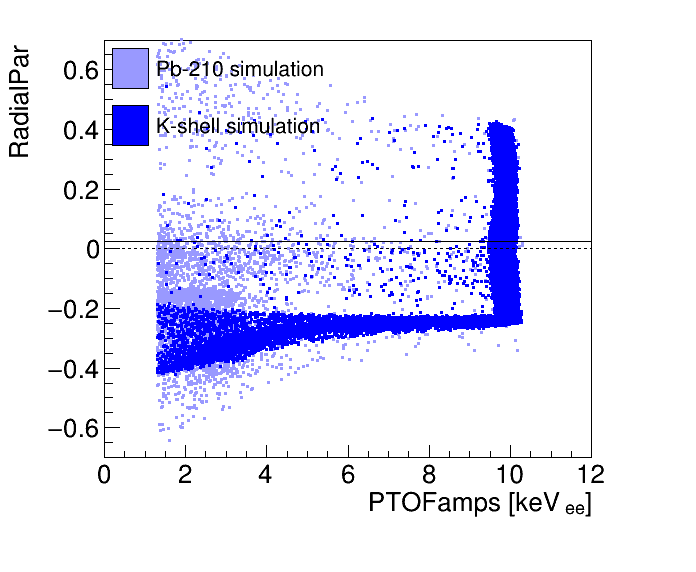

In [39]:
plt = ROOplot(_xlabel="PTOFamps [keV_{#kern[-0.1pt]{#lower[-0.5pt]{ee}}}]", _ylabel="RadialPar", _xlim=True, _xlow=0, _xhigh=12, _ylim=True, _ylow=-0.7, _yhigh=0.7)
plt.createScatter(RQs['Pb']['calib_PTOFamps'][RQs['Pb']['Kshell_cut']], RQs['Pb']['RadialPar'][RQs['Pb']['Kshell_cut']], color = ROOT.kBlue-9, label = 'Pb-210 simulation', size = 0.4)
plt.createScatter(RQs['K']['calib_PTOFamps'][RQs['K']['Kshell_cut']], RQs['K']['RadialPar'][RQs['K']['Kshell_cut']], color = ROOT.kBlue, label = 'K-shell simulation', size = 0.4)
#plt.createScatter(RQs['data']['calib_PTOFamps'][RQs['data']['Kshell_cut']], RQs['data']['RadialPar'][RQs['data']['Kshell_cut']], color = ROOT.kBlack, label = 'CUTE data', size = 0.4)
plt.draw("AP", "P ")
graphs = plt.getGraphs()

line1 = ROOT.TLine(0, 0, 12, 0)
line1.SetLineColor(ROOT.kBlack)
line1.SetLineStyle(2)
line1.SetLineWidth(1)
line1.Draw("same")

line2 = ROOT.TLine(0, 0.025, 12, 0.025)
line2.SetLineColor(ROOT.kBlack)
line2.SetLineStyle(1)
line2.SetLineWidth(1)
line2.Draw("same")

legend = ROOT.TLegend(0.15, 0.73, 0.45, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
for g, label in graphs:
    legend.AddEntry(g, label, "f")
legend.SetTextSize(0.04)

legend.Draw()

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c


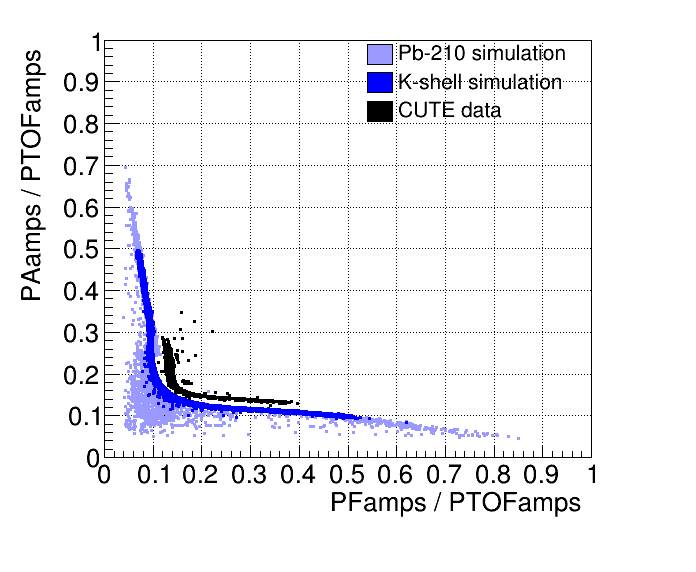

In [29]:
plt = ROOplot(700, 600, _xlabel="PFamps / PTOFamps", _ylabel="PAamps / PTOFamps", _xlim=True, _xlow=0, _xhigh=1, _ylim=True, _ylow=0, _yhigh=1)

plt.createScatter((RQs['Pb']['F'] / RQs['Pb']['PTOFamps'])[RQs['Pb']['Kshell_cut']], (RQs['Pb']['A'] / RQs['Pb']['PTOFamps'])[RQs['Pb']['Kshell_cut']], color = ROOT.kBlue-9, label = "Pb-210 simulation", size=0.4)
plt.createScatter((RQs['K']['F'] / RQs['K']['PTOFamps'])[RQs['K']['Kshell_cut']], (RQs['K']['A'] / RQs['K']['PTOFamps'])[RQs['K']['Kshell_cut']], color = ROOT.kBlue, label = "K-shell simulation", size=0.4)
plt.createScatter((RQs['data']['F'] / RQs['data']['PTOFamps'])[RQs['data']['Kshell_cut']], (RQs['data']['A'] / RQs['data']['PTOFamps'])[RQs['data']['Kshell_cut']], color = ROOT.kBlack, label = "CUTE data", size=0.4)

plt.draw("AP", "P ", grid=True)

graphs = plt.getGraphs()

legend = ROOT.TLegend(0.52, 0.78, 0.73, 0.93)
legend.SetBorderSize(0)
legend.SetFillStyle(0)
legend.SetTextSize(0.04)
for g, label in graphs:
    legend.AddEntry(g, label, "f")

legend.Draw()

In [30]:
thresholds = np.arange(-1, 1, 0.02)
sim_Kcount = sum(RQs['K']['Kshell_cut'])
sim_Pbcount = sum(RQs['Pb']['Kshell_cut'])
data_Kcount = sum(RQs['data']['Kshell_cut'])

simK_thresh = []
simPb_thresh = []
data_thresh = []

for threshold in thresholds:
    simK_thresh.append(sum(RQs['K']['Kshell_cut'] & (RQs['K']['RadialPar'] > threshold)))
    simPb_thresh.append(sum(RQs['Pb']['Kshell_cut'] & (RQs['Pb']['RadialPar'] > threshold)))
    data_thresh.append(sum(RQs['data']['Kshell_cut'] & (RQs['data']['RadialPar'] > threshold)))

In [31]:
simK_total = np.full_like(thresholds, sim_Kcount, dtype=int)
simPb_total = np.full_like(thresholds, sim_Pbcount, dtype=int)
data_total = np.full_like(thresholds, data_Kcount, dtype=int)

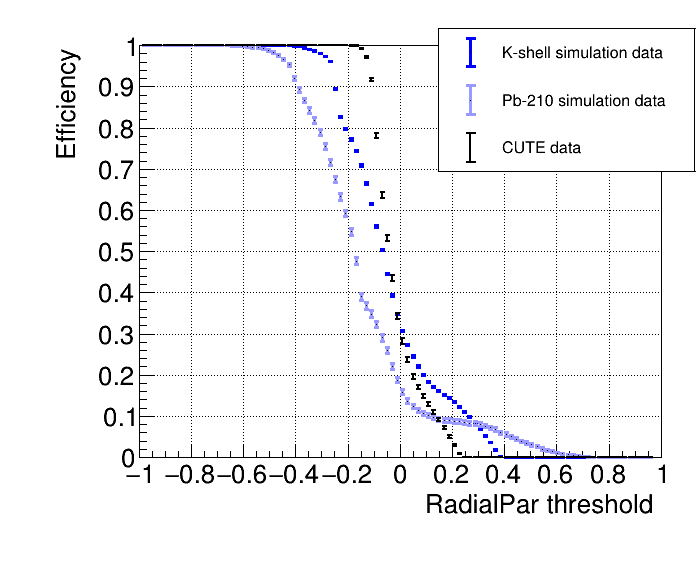

In [32]:
c = ROOT.TCanvas("c_eff", "", 700, 600)
bins_start = thresholds[0] - np.diff(thresholds)[0]/2
bins_end = thresholds[-1] - np.diff(thresholds)[0]/2
nbins = len(thresholds)
bindiff = np.round((bins_end - bins_start) / nbins, 2)

eff_simK = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_simPb = ROOT.TEfficiency("eff_sim", " ; ; ", nbins, bins_start, bins_end)
eff_data = ROOT.TEfficiency("eff_data", " ; ; ", nbins, bins_start, bins_end)

for i, (t, p, tot) in enumerate(zip(thresholds, simK_thresh, simK_total)):
    eff_simK.SetTotalEvents(i+1, int(tot))
    eff_simK.SetPassedEvents(i+1, int(p))

for i, (t, p, tot) in enumerate(zip(thresholds, simPb_thresh, simPb_total)):
    eff_simPb.SetTotalEvents(i+1, int(tot))
    eff_simPb.SetPassedEvents(i+1, int(p))

for i, (t, p, tot) in enumerate(zip(thresholds, data_thresh, data_total)):
    eff_data.SetTotalEvents(i+1, int(tot))
    eff_data.SetPassedEvents(i+1, int(p))

g1 = eff_simK.CreateGraph()
for i in range(g1.GetN()):
    g1.SetPointEXlow(i, 0)
    g1.SetPointEXhigh(i, 0)
    
g1.SetLineColor(ROOT.kBlue)
g1.SetLineWidth(3)
g1.GetXaxis().SetTitle("RadialPar threshold")
g1.GetYaxis().SetTitle(f"Efficiency")
g1.GetXaxis().SetLabelSize(0.05)
g1.GetYaxis().SetLabelSize(0.05)
g1.GetXaxis().SetTitleSize(0.05)
g1.GetYaxis().SetTitleSize(0.05)
g1.SetMaximum(1)
g1.SetMinimum(0)

g2 = eff_simPb.CreateGraph()
for i in range(g2.GetN()):
    g2.SetPointEXlow(i, 0)
    g2.SetPointEXhigh(i, 0)

g2.SetLineColor(ROOT.kBlue-9)
g2.SetLineWidth(3)

g3 = eff_data.CreateGraph()
for i in range(g2.GetN()):
    g3.SetPointEXlow(i, 0)
    g3.SetPointEXhigh(i, 0)
    
g3.SetLineColor(ROOT.kBlack)
g3.SetLineWidth(2)

#f1 = ROOT.TF1("f", "[0]*pow(x - [1], 2) + [2]", -0.07, 0.07)
#f1.SetParameters(7.7395, 0.15070, 0.20364)
#f1.SetParLimits(0, 0, 1e3)
#f1.SetParLimits(1, 0, 0.2)
#f1.SetLineColor(ROOT.kBlue-9)
#f1.SetLineStyle(2)
#f1.SetLineWidth(1)
#g1.Fit(f1, "", "", -0.07, 0.07)

#a1  = f1.GetParameter(0)
#a1_err = f1.GetParError(0)
#x01 = f1.GetParameter(1)
#x01_err = f1.GetParError(1)
#b1  = f1.GetParameter(2)
#b1_err = f1.GetParError(2)

#f2 = ROOT.TF1("f", "[0]*pow(x - [1], 2) + [2]", -0.07, 0.07)
#f2.SetParameters(20.792272, 0.09737, 0.196625) 
#f2.SetParLimits(0, 0, 1e3) 
#f2.SetParLimits(1, 0, 0.2) 
#f2.SetLineColor(ROOT.kBlack)
#f2.SetLineStyle(2)
#f2.SetLineWidth(1)
#g2.Fit(f2, "", "", -0.07, 0.07)

#a2  = f2.GetParameter(0)
#a2_err = f2.GetParError(0)
#x02 = f2.GetParameter(1)
#x02_err = f2.GetParError(1)
#b2  = f2.GetParameter(2)
#b2_err = f2.GetParError(2)

g1.GetXaxis().SetLimits(-1, 1)

g1.Draw("AP")
g2.Draw("P SAME")
g3.Draw("P SAME")
#f1.Draw("SAME")
#f2.Draw("SAME")

legend = ROOT.TLegend(0.63, 0.7, 1, 0.95)
legend.SetBorderSize(1)
legend.SetFillStyle(1001)
legend.SetFillColor(ROOT.kWhite)
legend.AddEntry(g1, "K-shell simulation data", "ep")
#legend.AddEntry(f1, "a (x - x_{0})^{2} + b", "l")
#legend.AddEntry(0, f"a = {a1:.3}" + " #pm " + f"{a1_err:.1}", "")
#legend.AddEntry(0, "x_{0}" + f" = {x01:.2}" + " #pm " + f"{x01_err:.1}", "")
#legend.AddEntry(0, f"b = {b1:.3}" + " #pm " + f"{b1_err:.1}", "")
legend.AddEntry(g2, "Pb-210 simulation data", "ep")
legend.AddEntry(g3, "CUTE data", "ep")
#legend.AddEntry(f2, "a (x - x_{0})^{2} + b", "l")
#legend.AddEntry(0, f"a = 21." + " #pm " + f"1.", "")
#legend.AddEntry(0, "x_{0}" + f" = {x02:.2}" + " #pm " + f"{x02_err:.1}", "")
#legend.AddEntry(0, f"b = {b2:.2}" + " #pm " + f"{b2_err:.1}", "")
legend.SetTextSize(0.03)

legend.Draw()
c.SetLeftMargin(0.2)
c.SetBottomMargin(0.2)
c.SetRightMargin(0.05)
c.SetTopMargin(0.08)
c.SetGrid(1, 1)

c.Draw()